## Arboles de decisión para predicción

In [1]:
import pandas as pd

In [5]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Aprendizaje supervisado para el pronostico/cardekho_data.csv')

Mounted at /content/drive


In [6]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [7]:
df.shape

(301, 9)

In [8]:
from sklearn.model_selection import train_test_split

# Se seleccionan la variable a predecir y las variables predictoras
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (240, 8)
Testing set shape: (61, 8)


In [9]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

# Variables categoricas
categorical_features = ['Car_Name', 'Fuel_Type', 'Seller_Type', 'Transmission']

# one-hot encoding para las variables categoricas
preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(handle_unknown='ignore'), categorical_features)],
    remainder='passthrough' # Mantener las columnas numericas como estaban
)

# Crear un modelo de arboles de decision para regresion
model = Pipeline(steps=[('preprocessor', preprocessor),
                      ('regressor', DecisionTreeRegressor(random_state=42))])

# Entrenar el modelo
model.fit(X_train, y_train)

# hacer las predicciones con el conjunto de prueba
y_pred = model.predict(X_test)

# Evaluar el modelo
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Squared Error: 1.0399049180327873
R-squared: 0.9548565864644408


In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score


categorical_features = ['Car_Name', 'Fuel_Type', 'Seller_Type', 'Transmission']

preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(handle_unknown='ignore'), categorical_features)],
    remainder='passthrough' # Keep other columns (numerical) as they are
)

linear_model = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', LinearRegression())])
linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print(f"Linear Regression Mean Squared Error: {mse_linear}")
print(f"Linear Regression R-squared: {r2_linear}")

Linear Regression Mean Squared Error: 2.6677460908209834
Linear Regression R-squared: 0.8841902149923231


In [13]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import pandas as pd

# Extract the fitted preprocessor from the linear model pipeline
fitted_preprocessor = linear_model.named_steps['preprocessor']

# Transform X_train using the fitted preprocessor
X_train_transformed = fitted_preprocessor.transform(X_train)

# Get feature names after preprocessing
try:
    feature_names_raw = fitted_preprocessor.get_feature_names_out()
except AttributeError:
    # Fallback for older scikit-learn versions
    ohe_feature_names = fitted_preprocessor.named_transformers_['onehot'].get_feature_names_out(categorical_features)
    passthrough_features = [col for col in X_train.columns if col not in categorical_features]
    feature_names_raw = list(ohe_feature_names) + passthrough_features

# Sanitize feature names for use in statsmodels formula
feature_names_sanitized = [col.replace(' ', '_').replace('[', '_').replace(']', '_').replace('-', '_').replace('(', '_').replace(')', '_').replace('/', '_') for col in feature_names_raw]

# Convert the sparse matrix to a DataFrame with sanitized column names
X_train_df_formula = pd.DataFrame(X_train_transformed.toarray(), columns=feature_names_sanitized, index=X_train.index)

# Combine y_train and X_train_df_formula into a single DataFrame for smf.ols
train_data_for_ols = X_train_df_formula.copy()
train_data_for_ols['Selling_Price'] = y_train

# Construct the formula string
independent_vars = ' + '.join([col for col in train_data_for_ols.columns if col != 'Selling_Price'])
formula = 'Selling_Price ~ ' + independent_vars

# Fit the OLS model using statsmodels.formula.api
ols_model = smf.ols(formula=formula, data=train_data_for_ols).fit()

# Print the ANOVA table (Type II ANOVA is common for regression)
anova_table = sm.stats.anova_lm(ols_model, typ=2)
print("ANOVA Table for Linear Regression Model:")
print(anova_table)

# Print the regression equation (model summary)
print("\nRegression Equation (Model Summary):")
print(ols_model.summary())

SyntaxError: invalid syntax (<unknown>, line 1)

In [12]:
from sklearn.ensemble import RandomForestRegressor

categorical_features = ['Car_Name', 'Fuel_Type', 'Seller_Type', 'Transmission']

preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(handle_unknown='ignore'), categorical_features)],
    remainder='passthrough'
)

rf_model = Pipeline(steps=[('preprocessor', preprocessor),
                           ('regressor', RandomForestRegressor(random_state=42))])
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest Mean Squared Error: {mse_rf}")
print(f"Random Forest R-squared: {r2_rf}")

Random Forest Mean Squared Error: 0.791234848852459
Random Forest R-squared: 0.9656516270227256


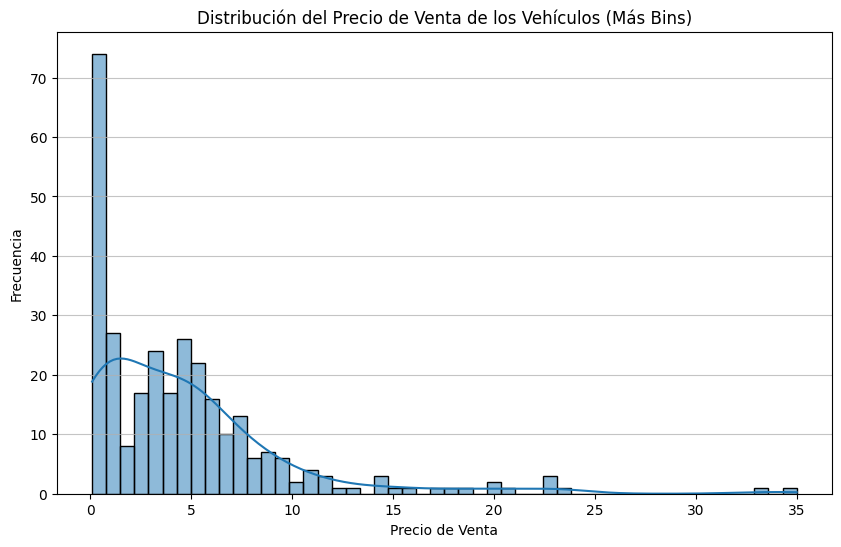

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['Selling_Price'], kde=True, bins=50)
plt.title('Distribución del Precio de Venta de los Vehículos (Más Bins)')
plt.xlabel('Precio de Venta')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.75)
plt.show()

LA TERCERA PARTE DE LOS CARROS ESTA POR DEBAJO DE LOS 2000 USD (LA MAYORIA DE LOS CARROS SON MUY BARATOS), ENTONCES EL ERROR DE 790 USD SI ES ALTO

EN ESTE ANALISIS TENGO UN PROBLEMA, HAY CARROS Y MOTOS ASI QUE TENGO QUE HACER UN ANALISIS DIVIDIDO PARA CARROS Y PARA MOTOS